# Model Evaluation, Results and model interpretability:

In this notebook we explore and compare the performance of various machine learning models in the two hurdles of our proposed framework: predicting readmission (Stage 1) and predicting early versus late readmission (Stage 2). We measure model performance using relevant metrics for imbalanced classification: AUC-ROC, PR-AUC, accuracy, precision, recall and F1-score. Specifically we are interested in F1-score and recall of the positive class since it is medically significant.

To improve model performance we fine-tune the decision thresholds to find the optimal precision-recall trade-off to optimize the model in terms of high-risk patient identification. We utilize cross-validation during training of our models to avoid over-fitting and increase generalizability of our model.

We investigate model interpretability using SHAP (SHapley Additive exPlanations). We investigate feature contributions in both global and local perspectives using the SHAP values. For determining feature importance we analyze mean absolute SHAP values to compare the factors most strongly contributing to predictions in each hurdle.

Model artefact loaded
Best Stage 1 model: XGBoost
Best Stage 2 model: XGBoost
Number of features: 59

CROSS-VALIDATION SUMMARY (PR-AUC)

Stage 1
  Logistic Regression: 0.4990
  Decision Tree: 0.4962
  Random Forest: 0.5540
  XGBoost: 0.5640

Stage 2
  Logistic Regression: 0.2609
  Decision Tree: 0.2755
  Random Forest: 0.2869
  XGBoost: 0.3340


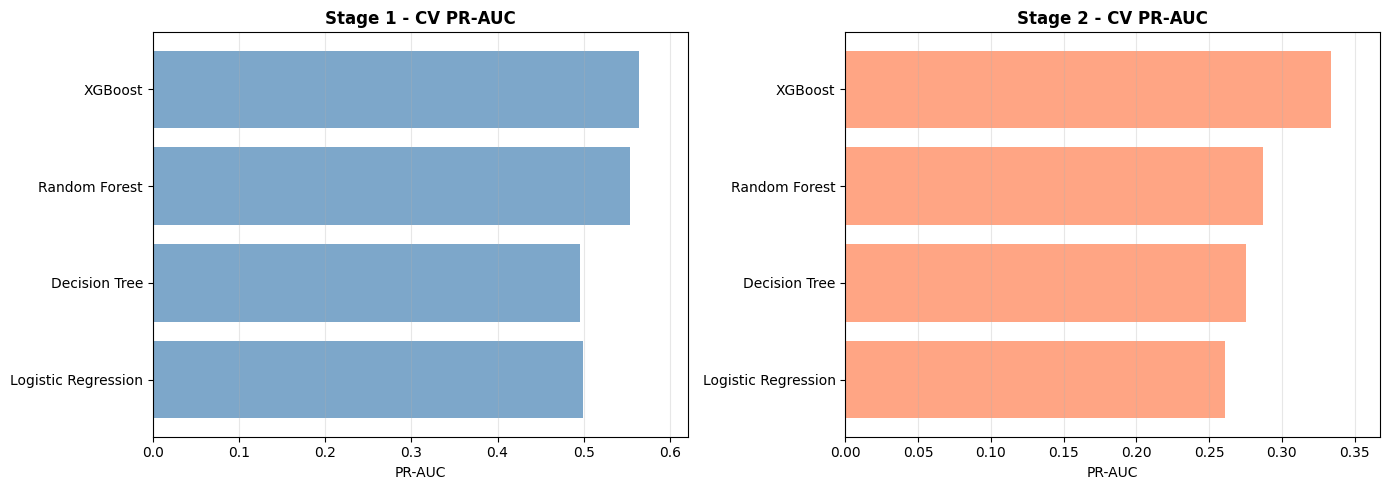


STAGE 1 - DEFAULT THRESHOLD RESULTS
              Model  Threshold  AUC-ROC  PR-AUC  Accuracy  F1_weighted  F1_positive  Precision_positive  Recall_positive
            XGBoost        0.5   0.6597  0.5741    0.6154       0.6182       0.5716              0.5292           0.6215
      Random Forest        0.5   0.6492  0.5628    0.6245       0.6191       0.5108              0.5528           0.4747
      Decision Tree        0.5   0.6130  0.5037    0.6017       0.5906       0.4543              0.5232           0.4014
Logistic Regression        0.5   0.5984  0.4914    0.5961       0.5844       0.4445              0.5145           0.3913

STAGE 1 - TUNED THRESHOLD RESULTS
              Model  Threshold  AUC-ROC  PR-AUC  Accuracy  F1_weighted  F1_positive  Precision_positive  Recall_positive
            XGBoost       0.39   0.6597  0.5741    0.5320       0.5010       0.6036              0.4641           0.8629
      Random Forest       0.36   0.6492  0.5628    0.5022       0.4484       0.59

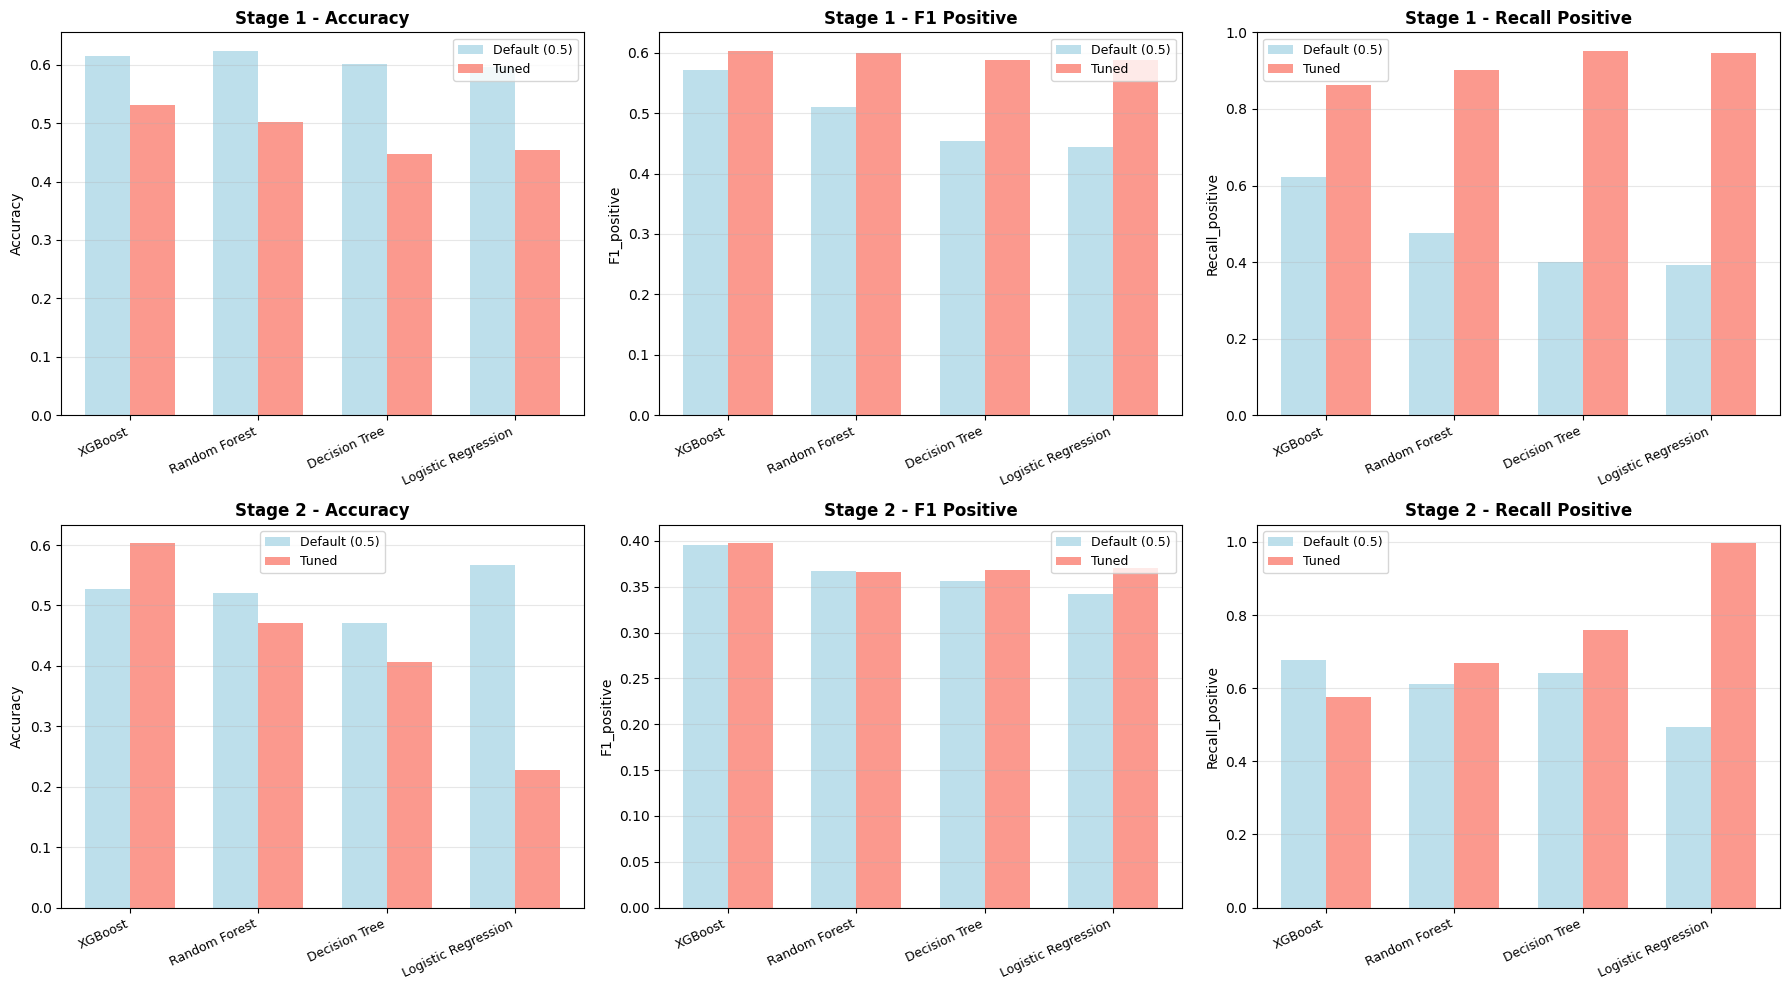

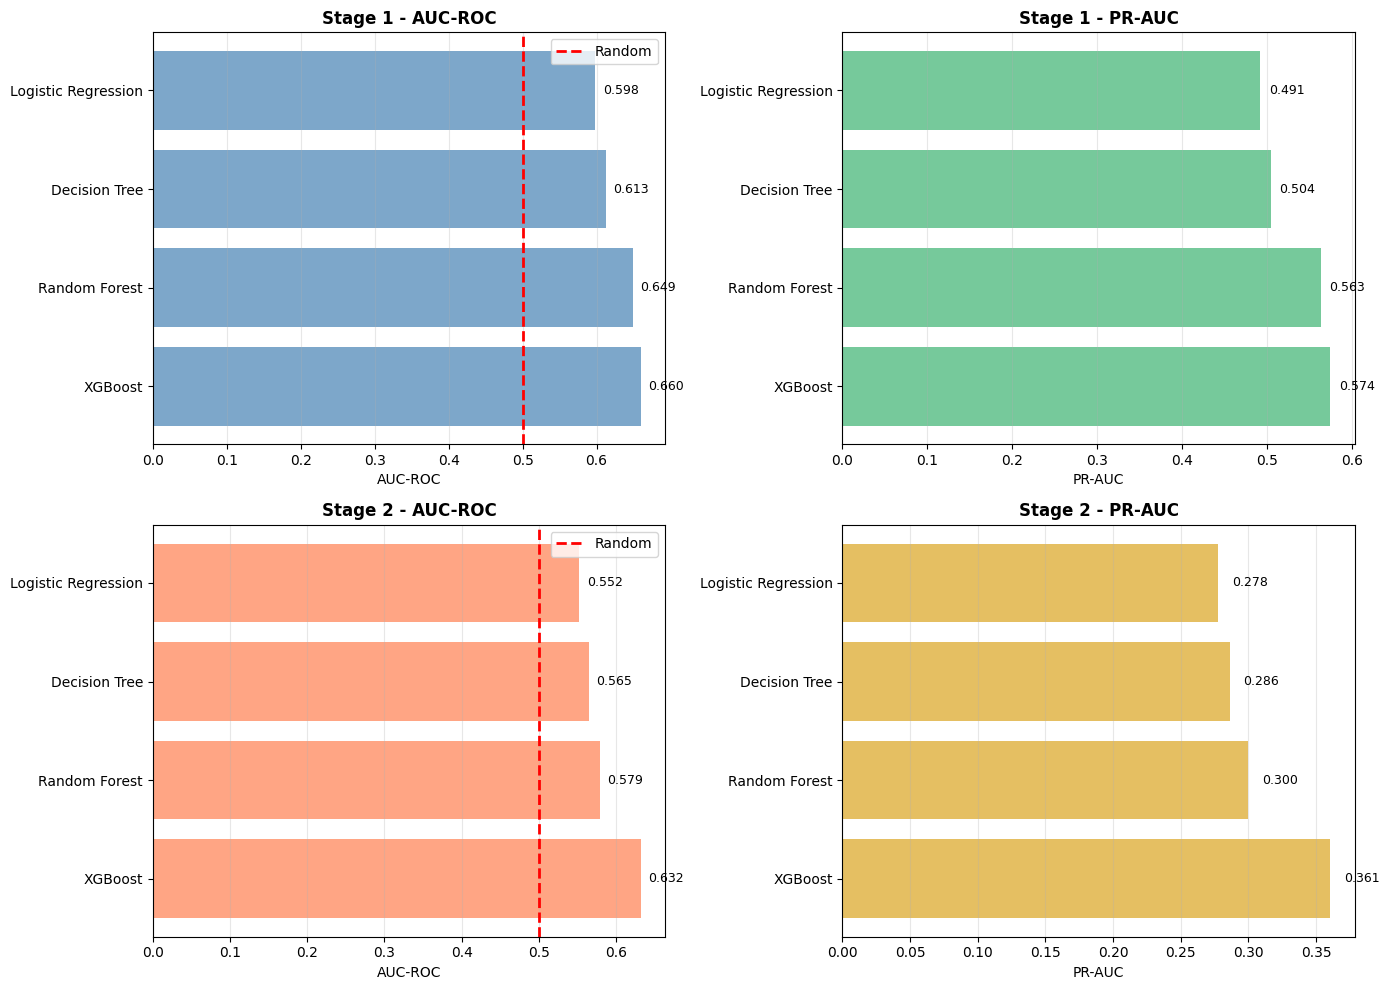

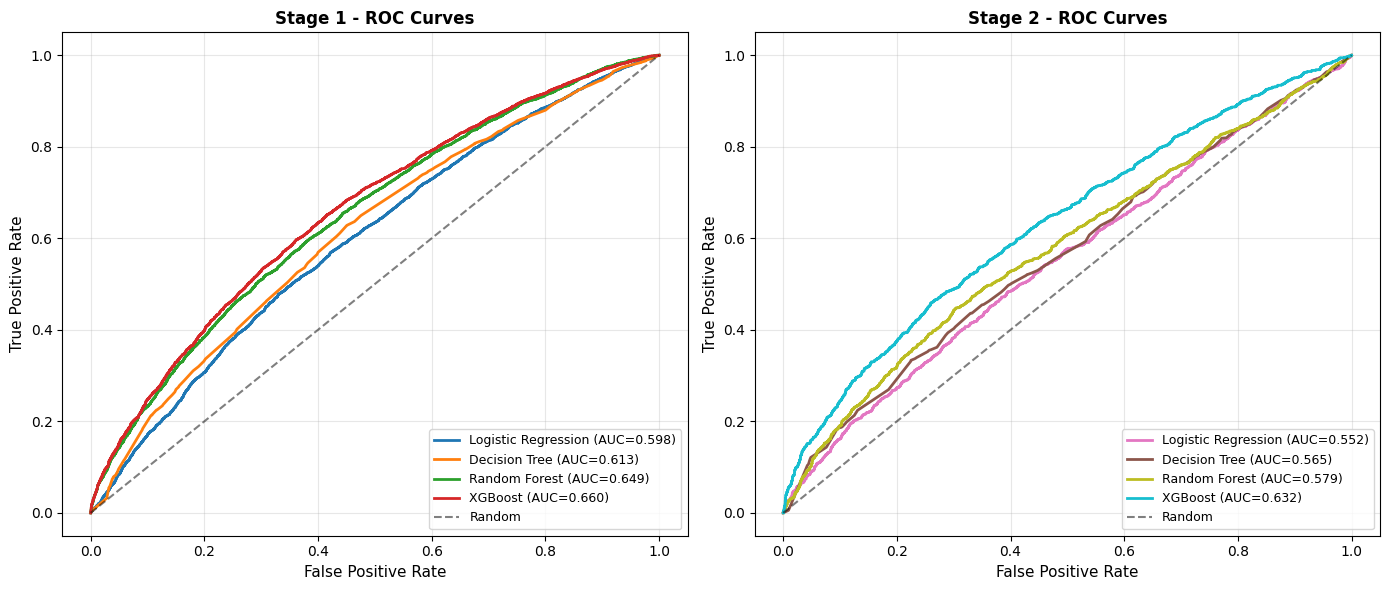

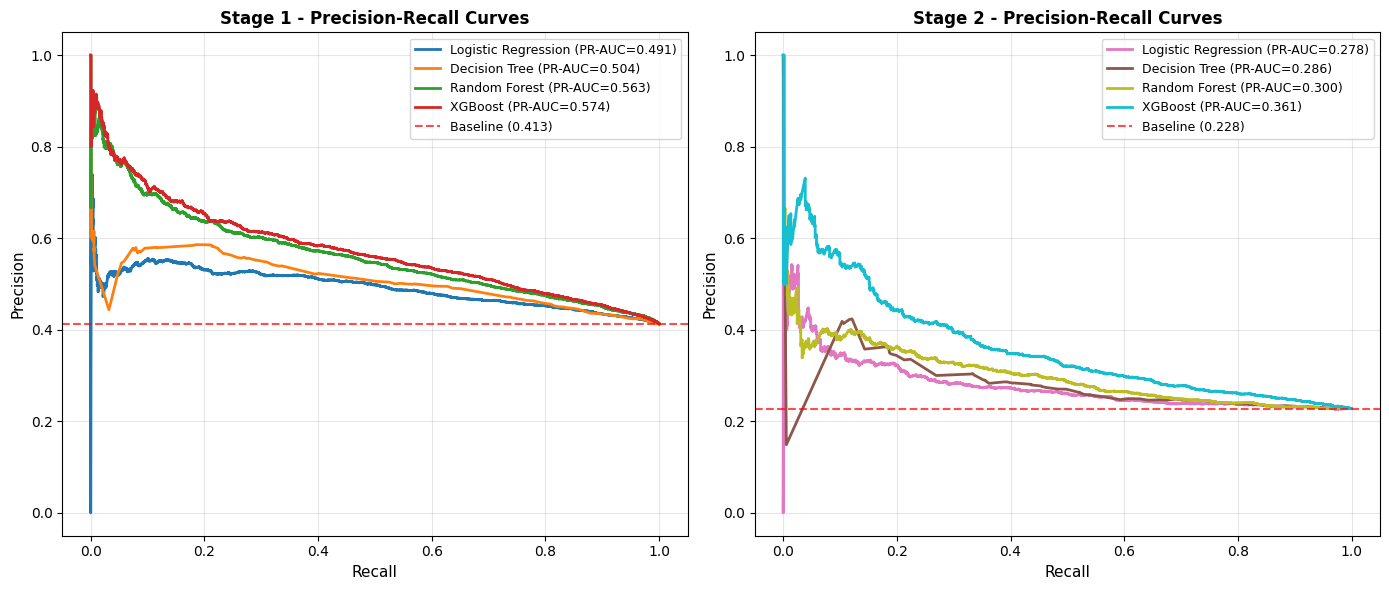

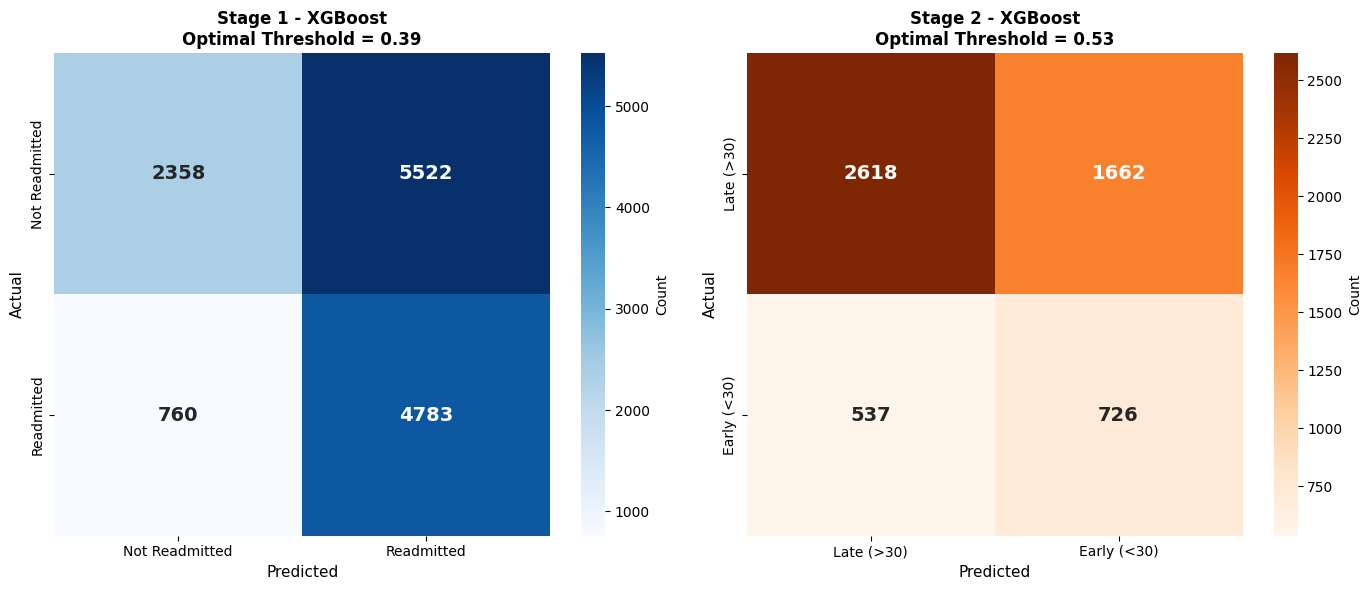


CLASSIFICATION REPORT - Stage 1 (XGBoost)
                precision    recall  f1-score   support

Not Readmitted       0.76      0.30      0.43      7880
    Readmitted       0.46      0.86      0.60      5543

      accuracy                           0.53     13423
     macro avg       0.61      0.58      0.52     13423
  weighted avg       0.64      0.53      0.50     13423


CLASSIFICATION REPORT - Stage 2 (XGBoost)
              precision    recall  f1-score   support

  Late (>30)       0.83      0.61      0.70      4280
 Early (<30)       0.30      0.57      0.40      1263

    accuracy                           0.60      5543
   macro avg       0.57      0.59      0.55      5543
weighted avg       0.71      0.60      0.63      5543


ERROR ANALYSIS

Stage 1 error counts:
error_type
Correct           7141
False Positive    5522
False Negative     760
Name: count, dtype: int64

Stage 2 error counts:
error_type
Correct           3344
False Positive    1662
False Negative     537


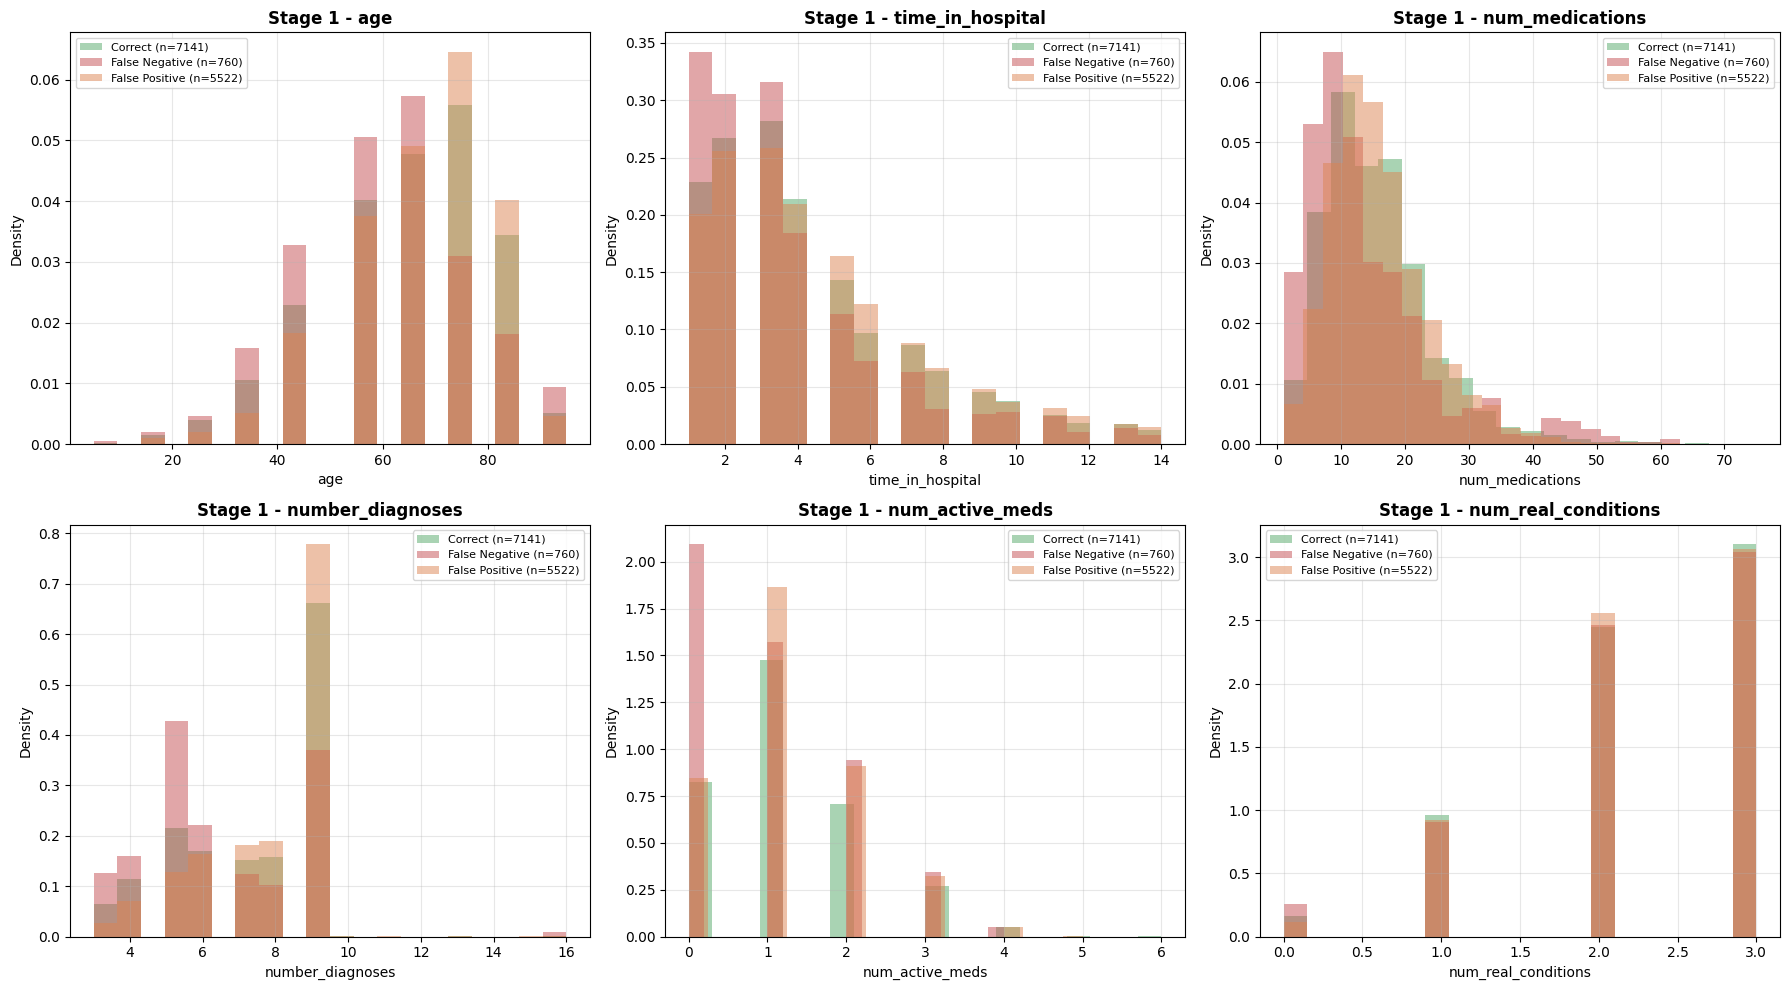

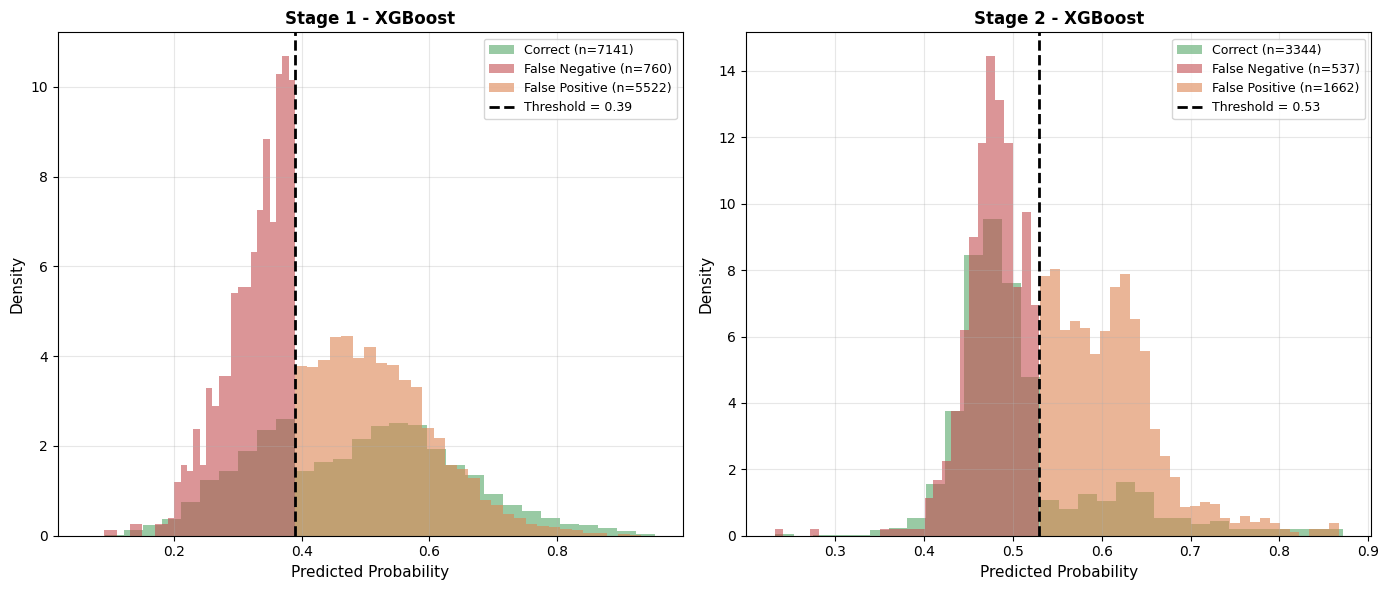


COMBINED HURDLE MODEL OUTPUT
Mean P(early readmission): 0.1200
Median P(early readmission): 0.2782
Max P(early readmission): 0.7089
Patients with P(early readmission) > 0: 5543


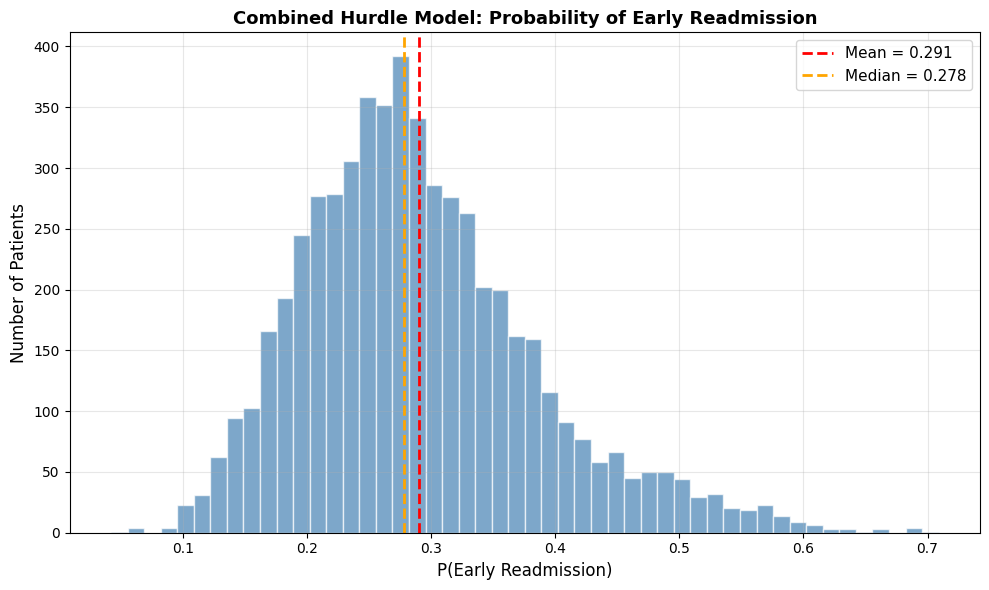


FINAL MODEL SUMMARY

Stage 1 (Readmission Prediction):
  Best Model: XGBoost
  Test AUC-ROC: 0.6597
  Test PR-AUC: 0.5741
  Optimal Threshold: 0.39
  F1-Score (tuned): 0.6036
  Recall: 0.8629
  Precision: 0.4641

Stage 2 (Early vs Late Readmission):
  Best Model: XGBoost
  Test AUC-ROC: 0.6320
  Test PR-AUC: 0.3607
  Optimal Threshold: 0.53
  F1-Score (tuned): 0.3977
  Recall: 0.5748
  Precision: 0.3040

All plots and tables saved to: c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs


In [2]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    roc_curve,
    precision_recall_curve,
)

# LOAD SAVED MODEL 
BASE_DIR = Path.cwd().parents[0]
MODEL_FILE = BASE_DIR / "models" / "trained_model.pkl"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(MODEL_FILE, "rb") as f:
    artefact = pickle.load(f)

cv_summary = artefact["cv_summary"]

stage1_outputs = artefact["stage1_outputs"]
stage2_outputs = artefact["stage2_outputs"]

df_stage1_default = artefact["stage1_default_table"].copy()
df_stage1_tuned = artefact["stage1_tuned_table"].copy()
df_stage2_default = artefact["stage2_default_table"].copy()
df_stage2_tuned = artefact["stage2_tuned_table"].copy()

best_model_stage1 = artefact["best_model_stage1"]
best_model_stage2 = artefact["best_model_stage2"]

y_test_s1 = artefact["y_test_s1"]
y_test_s2 = artefact["y_test_s2"]

X_test_model = artefact["X_test_model"].copy()
X_test_s2 = artefact["X_test_s2"].copy()

print("Model artefact loaded")
print(f"Best Stage 1 model: {best_model_stage1}")
print(f"Best Stage 2 model: {best_model_stage2}")
print(f"Number of features: {X_test_model.shape[1]}")


# 1. CROSS-VALIDATION SUMMARY
print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY (PR-AUC)")
print("="*60)

print("\nStage 1")
for name, score in cv_summary["Stage 1"].items():
    print(f"  {name}: {score:.4f}")

print("\nStage 2")
for name, score in cv_summary["Stage 2"].items():
    print(f"  {name}: {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stage1_names = list(cv_summary["Stage 1"].keys())
stage1_scores = list(cv_summary["Stage 1"].values())

stage2_names = list(cv_summary["Stage 2"].keys())
stage2_scores = list(cv_summary["Stage 2"].values())

axes[0].barh(stage1_names, stage1_scores, color='steelblue', alpha=0.7)
axes[0].set_title("Stage 1 - CV PR-AUC", fontsize=12, fontweight='bold')
axes[0].set_xlabel("PR-AUC")
axes[0].grid(True, alpha=0.3, axis="x")
axes[0].set_xlim(0, max(stage1_scores) * 1.1)

axes[1].barh(stage2_names, stage2_scores, color='coral', alpha=0.7)
axes[1].set_title("Stage 2 - CV PR-AUC", fontsize=12, fontweight='bold')
axes[1].set_xlabel("PR-AUC")
axes[1].grid(True, alpha=0.3, axis="x")
axes[1].set_xlim(0, max(stage2_scores) * 1.1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_summary.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. DEFAULT AND TUNED RESULTS TABLES
print("\n" + "="*60)
print("STAGE 1 - DEFAULT THRESHOLD RESULTS")
print("="*60)
print(df_stage1_default.to_string(index=False))

print("\n" + "="*60)
print("STAGE 1 - TUNED THRESHOLD RESULTS")
print("="*60)
print(df_stage1_tuned.to_string(index=False))

print("\n" + "="*60)
print("STAGE 2 - DEFAULT THRESHOLD RESULTS")
print("="*60)
print(df_stage2_default.to_string(index=False))

print("\n" + "="*60)
print("STAGE 2 - TUNED THRESHOLD RESULTS")
print("="*60)
print(df_stage2_tuned.to_string(index=False))

# Save tables
df_stage1_default.to_csv(OUTPUT_DIR / "stage1_default_metrics.csv", index=False)
df_stage1_tuned.to_csv(OUTPUT_DIR / "stage1_tuned_metrics.csv", index=False)
df_stage2_default.to_csv(OUTPUT_DIR / "stage2_default_metrics.csv", index=False)
df_stage2_tuned.to_csv(OUTPUT_DIR / "stage2_tuned_metrics.csv", index=False)


# 3. DEFAULT VS TUNED THRESHOLD COMPARISON
model_order_1 = df_stage1_default["Model"].tolist()
model_order_2 = df_stage2_default["Model"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plots = [
    (axes[0, 0], df_stage1_default, df_stage1_tuned, model_order_1, "Accuracy", "Stage 1 - Accuracy"),
    (axes[0, 1], df_stage1_default, df_stage1_tuned, model_order_1, "F1_positive", "Stage 1 - F1 Positive"),
    (axes[0, 2], df_stage1_default, df_stage1_tuned, model_order_1, "Recall_positive", "Stage 1 - Recall Positive"),
    (axes[1, 0], df_stage2_default, df_stage2_tuned, model_order_2, "Accuracy", "Stage 2 - Accuracy"),
    (axes[1, 1], df_stage2_default, df_stage2_tuned, model_order_2, "F1_positive", "Stage 2 - F1 Positive"),
    (axes[1, 2], df_stage2_default, df_stage2_tuned, model_order_2, "Recall_positive", "Stage 2 - Recall Positive"),
]

for ax, df_def, df_tun, model_order, metric, title in plots:
    x = np.arange(len(model_order))
    width = 0.35

    vals_def = df_def.set_index("Model")[metric].reindex(model_order).values
    vals_tun = df_tun.set_index("Model")[metric].reindex(model_order).values

    ax.bar(x - width/2, vals_def, width, label="Default (0.5)", alpha=0.8, color='lightblue')
    ax.bar(x + width/2, vals_tun, width, label="Tuned", alpha=0.8, color='salmon')

    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=25, ha="right", fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. AUC-ROC AND PR-AUC BARS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, df, title, color in [
    (axes[0, 0], df_stage1_default, "Stage 1 - AUC-ROC", 'steelblue'),
    (axes[0, 1], df_stage1_default, "Stage 1 - PR-AUC", 'mediumseagreen'),
    (axes[1, 0], df_stage2_default, "Stage 2 - AUC-ROC", 'coral'),
    (axes[1, 1], df_stage2_default, "Stage 2 - PR-AUC", 'goldenrod'),
]:
    metric = "AUC-ROC" if "AUC-ROC" in title else "PR-AUC"
    ax.barh(df["Model"], df[metric], color=color, alpha=0.7)
    if metric == "AUC-ROC":
        ax.axvline(0.5, color="red", linestyle="--", linewidth=2, label="Random")
        ax.legend()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric)
    ax.grid(True, alpha=0.3, axis="x")
    
    # Add value labels
    for i, v in enumerate(df[metric].values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "auc_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. ROC CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_s1 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, (name, item) in enumerate(stage1_outputs.items()):
    fpr, tpr, _ = roc_curve(y_test_s1, item["test_prob"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={item['default_result']['AUC-ROC']:.3f})", 
                 linewidth=2, color=colors_s1[i % len(colors_s1)])

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random", alpha=0.5)
axes[0].set_title("Stage 1 - ROC Curves", fontweight='bold', fontsize=12)
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.3)

colors_s2 = ['#e377c2', '#8c564b', '#bcbd22', '#17becf', '#7f7f7f']
for i, (name, item) in enumerate(stage2_outputs.items()):
    fpr, tpr, _ = roc_curve(y_test_s2, item["test_prob"])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={item['default_result']['AUC-ROC']:.3f})", 
                 linewidth=2, color=colors_s2[i % len(colors_s2)])

axes[1].plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random", alpha=0.5)
axes[1].set_title("Stage 2 - ROC Curves", fontweight='bold', fontsize=12)
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# 6. PRECISION-RECALL CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (name, item) in enumerate(stage1_outputs.items()):
    precision, recall, _ = precision_recall_curve(y_test_s1, item["test_prob"])
    axes[0].plot(recall, precision, label=f"{name} (PR-AUC={item['default_result']['PR-AUC']:.3f})", 
                 linewidth=2, color=colors_s1[i % len(colors_s1)])

# Baseline (prevalence)
baseline_s1 = y_test_s1.mean()
axes[0].axhline(baseline_s1, color='red', linestyle='--', linewidth=1.5, 
                label=f'Baseline ({baseline_s1:.3f})', alpha=0.7)
axes[0].set_title("Stage 1 - Precision-Recall Curves", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Recall", fontsize=11)
axes[0].set_ylabel("Precision", fontsize=11)
axes[0].legend(fontsize=9, loc='best')
axes[0].grid(True, alpha=0.3)

for i, (name, item) in enumerate(stage2_outputs.items()):
    precision, recall, _ = precision_recall_curve(y_test_s2, item["test_prob"])
    axes[1].plot(recall, precision, label=f"{name} (PR-AUC={item['default_result']['PR-AUC']:.3f})", 
                 linewidth=2, color=colors_s2[i % len(colors_s2)])

# Baseline (prevalence)
baseline_s2 = y_test_s2.mean()
axes[1].axhline(baseline_s2, color='red', linestyle='--', linewidth=1.5, 
                label=f'Baseline ({baseline_s2:.3f})', alpha=0.7)
axes[1].set_title("Stage 2 - Precision-Recall Curves", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].legend(fontsize=9, loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pr_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# 7. CONFUSION MATRICES + CLASSIFICATION REPORTS
best_stage1_item = stage1_outputs[best_model_stage1]
best_stage2_item = stage2_outputs[best_model_stage2]

cm_s1 = best_stage1_item["tuned_result"]["Confusion Matrix"]
cm_s2 = best_stage2_item["tuned_result"]["Confusion Matrix"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    cm_s1,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"],
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title(f"Stage 1 - {best_model_stage1}\nOptimal Threshold = {best_stage1_item['best_threshold']}", 
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel("Actual", fontsize=11)
axes[0].set_xlabel("Predicted", fontsize=11)

sns.heatmap(
    cm_s2,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[1],
    xticklabels=["Late (>30)", "Early (<30)"],
    yticklabels=["Late (>30)", "Early (<30)"],
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[1].set_title(f"Stage 2 - {best_model_stage2}\nOptimal Threshold = {best_stage2_item['best_threshold']}", 
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel("Actual", fontsize=11)
axes[1].set_xlabel("Predicted", fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

pred_best_s1 = (best_stage1_item["test_prob"] >= best_stage1_item["best_threshold"]).astype(int)
pred_best_s2 = (best_stage2_item["test_prob"] >= best_stage2_item["best_threshold"]).astype(int)

print("\n" + "="*60)
print(f"CLASSIFICATION REPORT - Stage 1 ({best_model_stage1})")
print("="*60)
print(classification_report(y_test_s1, pred_best_s1, target_names=["Not Readmitted", "Readmitted"]))

print("\n" + "="*60)
print(f"CLASSIFICATION REPORT - Stage 2 ({best_model_stage2})")
print("="*60)
print(classification_report(y_test_s2, pred_best_s2, target_names=["Late (>30)", "Early (<30)"]))

# 8. ERROR ANALYSIS
error_df_s1 = X_test_model.copy()
error_df_s1["y_true"] = y_test_s1.values
error_df_s1["y_prob"] = best_stage1_item["test_prob"]
error_df_s1["y_pred"] = pred_best_s1
error_df_s1["error_type"] = "Correct"
error_df_s1.loc[(error_df_s1["y_true"] == 1) & (error_df_s1["y_pred"] == 0), "error_type"] = "False Negative"
error_df_s1.loc[(error_df_s1["y_true"] == 0) & (error_df_s1["y_pred"] == 1), "error_type"] = "False Positive"

error_df_s2 = X_test_s2.copy()
error_df_s2["y_true"] = y_test_s2.values
error_df_s2["y_prob"] = best_stage2_item["test_prob"]
error_df_s2["y_pred"] = pred_best_s2
error_df_s2["error_type"] = "Correct"
error_df_s2.loc[(error_df_s2["y_true"] == 1) & (error_df_s2["y_pred"] == 0), "error_type"] = "False Negative"
error_df_s2.loc[(error_df_s2["y_true"] == 0) & (error_df_s2["y_pred"] == 1), "error_type"] = "False Positive"

print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)
print("\nStage 1 error counts:")
print(error_df_s1["error_type"].value_counts())

print("\nStage 2 error counts:")
print(error_df_s2["error_type"].value_counts())

# Save error analysis
error_summary = pd.DataFrame({
    'Stage': ['Stage 1', 'Stage 1', 'Stage 1', 'Stage 2', 'Stage 2', 'Stage 2'],
    'Error Type': ['Correct', 'False Negative', 'False Positive'] * 2,
    'Count': [
        (error_df_s1['error_type'] == 'Correct').sum(),
        (error_df_s1['error_type'] == 'False Negative').sum(),
        (error_df_s1['error_type'] == 'False Positive').sum(),
        (error_df_s2['error_type'] == 'Correct').sum(),
        (error_df_s2['error_type'] == 'False Negative').sum(),
        (error_df_s2['error_type'] == 'False Positive').sum(),
    ]
})
error_summary.to_csv(OUTPUT_DIR / "error_summary.csv", index=False)

# Clinical feature distributions by error type
clinical_features = [
    "age",
    "time_in_hospital",
    "num_medications",
    "number_diagnoses",
    "num_active_meds",
    "num_real_conditions",
]

colors_error = {
    "Correct": "#55A868",
    "False Negative": "#C44E52",
    "False Positive": "#DD8452",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, feature in enumerate(clinical_features):
    ax = axes[i // 3, i % 3]
    df_used = error_df_s1  # Use Stage 1 for all

    if feature not in df_used.columns:
        ax.text(0.5, 0.5, f'{feature}\nnot found', ha='center', va='center')
        continue

    for error_type, color in colors_error.items():
        sub = df_used[df_used["error_type"] == error_type]
        if len(sub) > 0:
            ax.hist(
                sub[feature],
                bins=20,
                alpha=0.5,
                density=True,
                label=f"{error_type} (n={len(sub)})",
                color=color,
            )

    ax.set_title(f"Stage 1 - {feature}", fontweight='bold')
    ax.set_ylabel("Density")
    ax.set_xlabel(feature)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_analysis_features.png", dpi=300, bbox_inches='tight')
plt.show()

# 9. PROBABILITY DISTRIBUTION BY ERROR TYPE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_used, model_name, threshold, stage in [
    (axes[0], error_df_s1, best_model_stage1, best_stage1_item["best_threshold"], "Stage 1"),
    (axes[1], error_df_s2, best_model_stage2, best_stage2_item["best_threshold"], "Stage 2"),
]:
    for error_type, color in colors_error.items():
        sub = df_used[df_used["error_type"] == error_type]
        if len(sub) > 0:
            ax.hist(
                sub["y_prob"],
                bins=30,
                alpha=0.6,
                density=True,
                label=f"{error_type} (n={len(sub)})",
                color=color,
            )

    ax.axvline(threshold, color="black", linestyle="--", linewidth=2, 
               label=f"Threshold = {threshold}")
    ax.set_title(f"{stage} - {model_name}", fontweight='bold', fontsize=12)
    ax.set_xlabel("Predicted Probability", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "probability_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

# 10. COMBINED HURDLE OUTPUT

p_readmitted = best_stage1_item["test_prob"]

p_early_given_readmitted = np.zeros(len(y_test_s1))
stage2_prob_series = pd.Series(best_stage2_item["test_prob"], index=y_test_s2.index)

for i, idx in enumerate(y_test_s1.index):
    if idx in stage2_prob_series.index:
        p_early_given_readmitted[i] = stage2_prob_series[idx]

p_early_readmission = p_readmitted * p_early_given_readmitted
mask = p_early_readmission > 0

print("\n" + "="*60)
print("COMBINED HURDLE MODEL OUTPUT")
print("="*60)
print(f"Mean P(early readmission): {p_early_readmission.mean():.4f}")
print(f"Median P(early readmission): {np.median(p_early_readmission[mask]):.4f}")
print(f"Max P(early readmission): {p_early_readmission.max():.4f}")
print(f"Patients with P(early readmission) > 0: {mask.sum()}")

plt.figure(figsize=(10, 6))
plt.hist(p_early_readmission[mask], bins=50, alpha=0.7, edgecolor="white", color='steelblue')
plt.xlabel("P(Early Readmission)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.title("Combined Hurdle Model: Probability of Early Readmission", fontweight='bold', fontsize=13)
plt.axvline(
    p_early_readmission[mask].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {p_early_readmission[mask].mean():.3f}",
)
plt.axvline(
    np.median(p_early_readmission[mask]),
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Median = {np.median(p_early_readmission[mask]):.3f}",
)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "combined_hurdle_probability.png", dpi=300, bbox_inches='tight')
plt.show()

# 11. SUMMARY REPORT

print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)

print(f"\nStage 1 (Readmission Prediction):")
print(f"  Best Model: {best_model_stage1}")
print(f"  Test AUC-ROC: {best_stage1_item['tuned_result']['AUC-ROC']:.4f}")
print(f"  Test PR-AUC: {best_stage1_item['tuned_result']['PR-AUC']:.4f}")
print(f"  Optimal Threshold: {best_stage1_item['best_threshold']}")
print(f"  F1-Score (tuned): {best_stage1_item['tuned_result']['F1_positive']:.4f}")
print(f"  Recall: {best_stage1_item['tuned_result']['Recall_positive']:.4f}")
print(f"  Precision: {best_stage1_item['tuned_result']['Precision_positive']:.4f}")

print(f"\nStage 2 (Early vs Late Readmission):")
print(f"  Best Model: {best_model_stage2}")
print(f"  Test AUC-ROC: {best_stage2_item['tuned_result']['AUC-ROC']:.4f}")
print(f"  Test PR-AUC: {best_stage2_item['tuned_result']['PR-AUC']:.4f}")
print(f"  Optimal Threshold: {best_stage2_item['best_threshold']}")
print(f"  F1-Score (tuned): {best_stage2_item['tuned_result']['F1_positive']:.4f}")
print(f"  Recall: {best_stage2_item['tuned_result']['Recall_positive']:.4f}")
print(f"  Precision: {best_stage2_item['tuned_result']['Precision_positive']:.4f}")

print("\n" + "="*60)
print("All plots and tables saved to:", OUTPUT_DIR)
print("="*60)


c:\Users\Israa Atike\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP ANALYSIS 

Model artifact loaded
Best Stage 1 model: XGBoost
Best Stage 2 model: XGBoost
Number of features: 59

STAGE 1 SHAP ANALYSIS

Using 2000 samples for SHAP analysis...
Using TreeExplainer for XGBoost...

 Generating SHAP summary plot (Stage 1)...


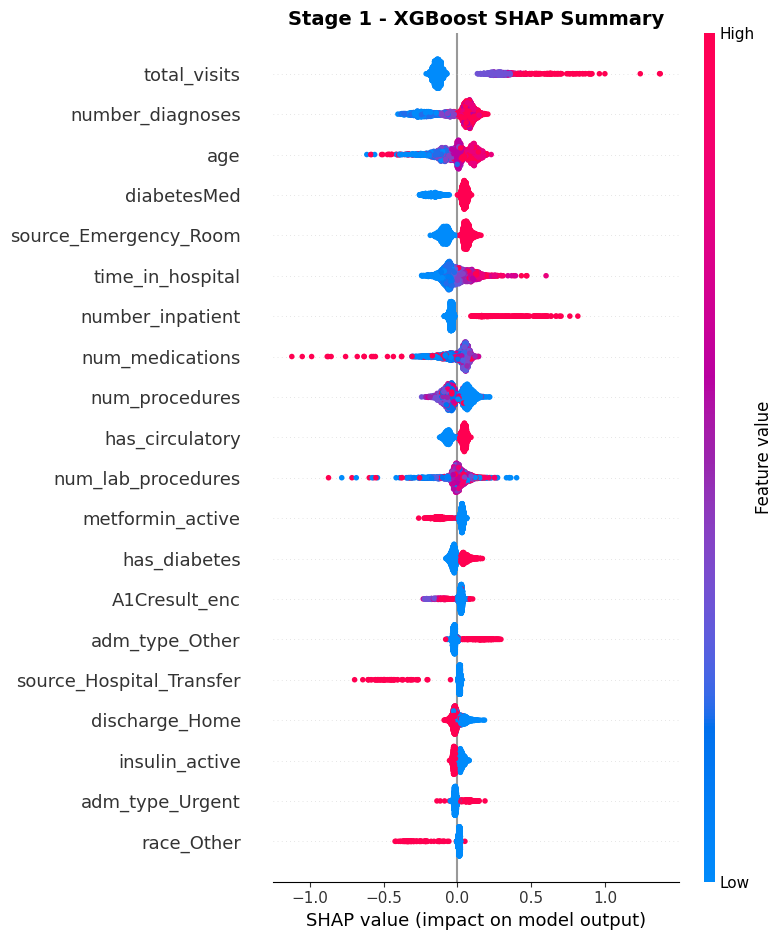


 Generating SHAP importance bar plot (Stage 1)...


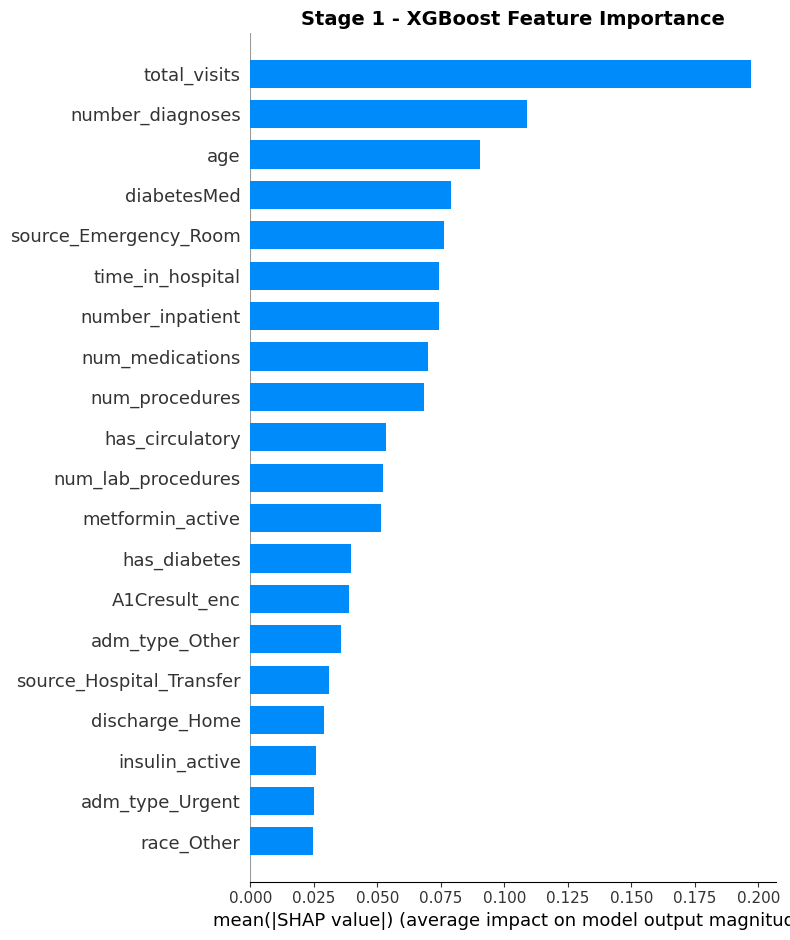


TOP 20 STAGE 1 FEATURES BY MEAN ABSOLUTE SHAP VALUE
                 feature  mean_abs_shap
            total_visits       0.197063
        number_diagnoses       0.109053
                     age       0.090444
             diabetesMed       0.079069
   source_Emergency_Room       0.076323
        time_in_hospital       0.074398
        number_inpatient       0.074293
         num_medications       0.069727
          num_procedures       0.068406
         has_circulatory       0.053355
      num_lab_procedures       0.052330
        metformin_active       0.051372
            has_diabetes       0.039472
           A1Cresult_enc       0.038907
          adm_type_Other       0.035544
source_Hospital_Transfer       0.031087
          discharge_Home       0.028868
          insulin_active       0.025951
         adm_type_Urgent       0.024958
              race_Other       0.024555

  No engineered features in top 20

STAGE 2 SHAP ANALYSIS

Using 2000 samples for SHAP analysis...
Using T

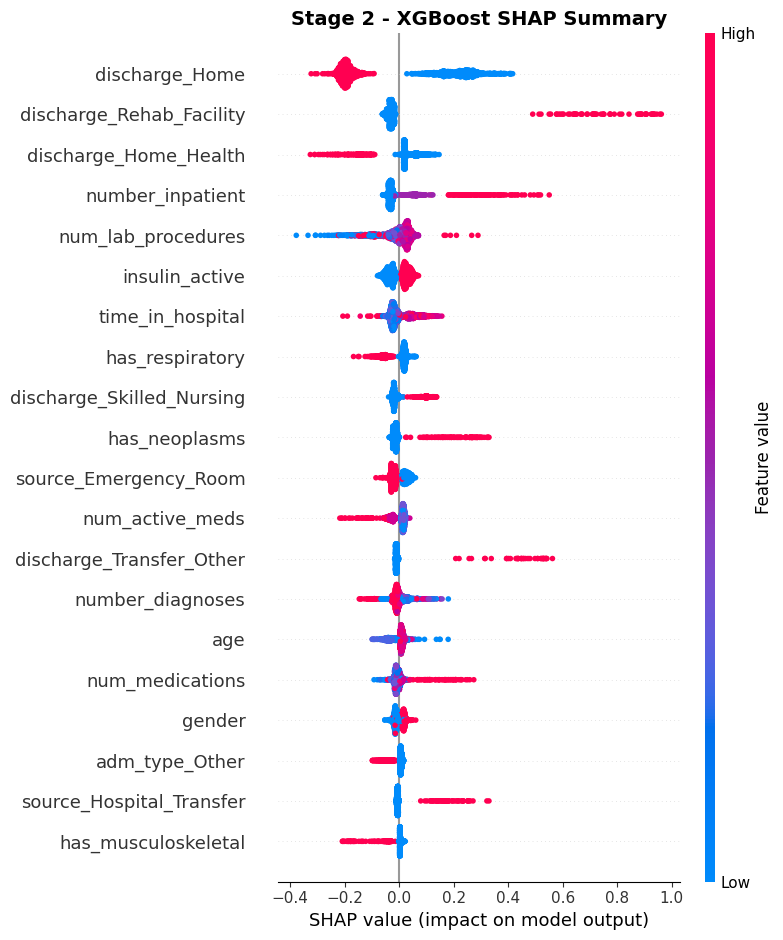


 Generating SHAP importance bar plot (Stage 2)...


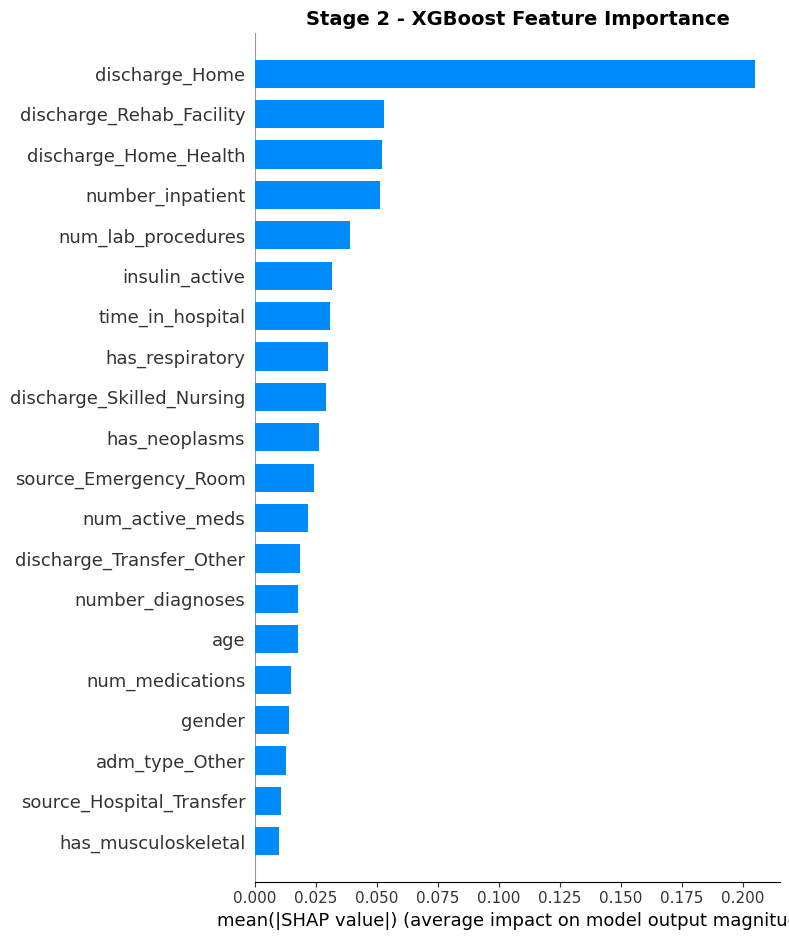


TOP 20 STAGE 2 FEATURES BY MEAN ABSOLUTE SHAP VALUE
                  feature  mean_abs_shap
           discharge_Home       0.204859
 discharge_Rehab_Facility       0.052974
    discharge_Home_Health       0.051983
         number_inpatient       0.051321
       num_lab_procedures       0.038791
           insulin_active       0.031372
         time_in_hospital       0.030661
          has_respiratory       0.029960
discharge_Skilled_Nursing       0.029063
            has_neoplasms       0.026028
    source_Emergency_Room       0.024003
          num_active_meds       0.021852
 discharge_Transfer_Other       0.018343
         number_diagnoses       0.017720
                      age       0.017625
          num_medications       0.014734
                   gender       0.014000
           adm_type_Other       0.012764
 source_Hospital_Transfer       0.010732
      has_musculoskeletal       0.009972

  No engineered features in top 20

FEATURE IMPORTANCE COMPARISON

Top 10 features by

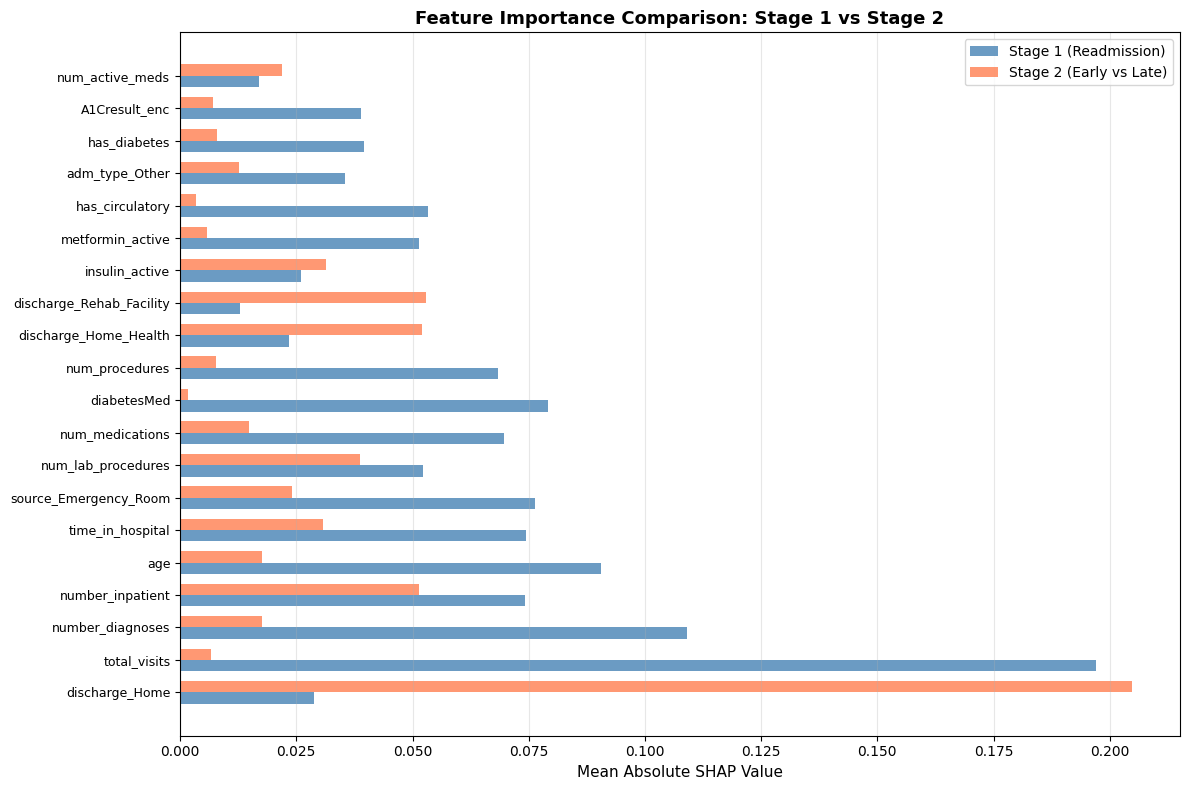

SAVING RESULTS

 Saved files:
  - c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs\shap_importance_stage1.csv
  - c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs\shap_importance_stage2.csv
  - c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs\feature_importance_comparison.csv
  - c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs\shap_summary_stage1.png
  - c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs\shap_importance_stage1.png
  - c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs\shap_summary_stage2.png
  - c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs\shap_importance_stage2.png
  - c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\outputs\feature_importance_comparison.png
SHAP ANALYSIS SUMMARY

Stage 1 (XGBoost):
  Most important feature: total_visits
  SHAP value: 0.1971

Stage 2 (XGBoost):


In [ ]:
# SHAP ANALYSIS FOR IMPROVED MODEL

from pathlib import Path
import pickle

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SETUP
BASE_DIR = Path.cwd().parents[0]
MODEL_FILE = BASE_DIR / "models" / "trained_model.pkl" 
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("SHAP ANALYSIS ")


# 1. LOAD MODEL 
with open(MODEL_FILE, "rb") as f:
    artefact = pickle.load(f)

stage1_outputs = artefact["stage1_outputs"]
stage2_outputs = artefact["stage2_outputs"]
best_model_stage1 = artefact["best_model_stage1"]
best_model_stage2 = artefact["best_model_stage2"]
X_test_model = artefact["X_test_model"]
X_test_s2 = artefact["X_test_s2"]
y_test_s1 = artefact["y_test_s1"]
y_test_s2 = artefact["y_test_s2"]

print(f"\nModel artifact loaded")
print(f"Best Stage 1 model: {best_model_stage1}")
print(f"Best Stage 2 model: {best_model_stage2}")
print(f"Number of features: {X_test_model.shape[1]}")

# 2. SELECT BEST MODELS
best_stage1_item = stage1_outputs[best_model_stage1]
best_stage2_item = stage2_outputs[best_model_stage2]

best_stage1_model = best_stage1_item["model"]
best_stage2_model = best_stage2_item["model"]

# Handle pipeline models

# XGBoost, RF, DT are standalone, but LR is in a pipeline
if hasattr(best_stage1_model, 'named_steps'):
    # It's a pipeline, extract the final model
    print(f"\n{best_model_stage1} is a pipeline, extracting final estimator...")
    stage1_model_for_shap = best_stage1_model.named_steps['model']
    # For pipeline, we need to transform data through SMOTE 
    use_pipeline_s1 = True
else:
    stage1_model_for_shap = best_stage1_model
    use_pipeline_s1 = False

if hasattr(best_stage2_model, 'named_steps'):
    print(f"{best_model_stage2} is a pipeline, extracting final estimator...")
    stage2_model_for_shap = best_stage2_model.named_steps['model']
    use_pipeline_s2 = True
else:
    stage2_model_for_shap = best_stage2_model
    use_pipeline_s2 = False

# 3. SHAP ANALYSIS — STAGE 1
print("\n" + "="*70)
print("STAGE 1 SHAP ANALYSIS")
print("="*70)

# Use a sample for speed (SHAP is computationally expensive)
sample_n = min(2000, len(X_test_model))
X_shap_s1 = X_test_model.sample(sample_n, random_state=42)

print(f"\nUsing {sample_n} samples for SHAP analysis...")

# Check if model is tree-based (TreeExplainer is faster and more accurate)
if best_model_stage1 in ['XGBoost', 'Random Forest', 'Decision Tree']:
    print(f"Using TreeExplainer for {best_model_stage1}...")
    explainer_s1 = shap.TreeExplainer(stage1_model_for_shap)
    shap_values_s1 = explainer_s1.shap_values(X_shap_s1)
else:
    print(f"Using KernelExplainer for {best_model_stage1} (this may take a while)...")
    # For non-tree models like Logistic Regression
    # Use a background dataset (100 samples)
    background = shap.sample(X_test_model, 100, random_state=42)
    
    if use_pipeline_s1:
        # For pipeline models, use predict_proba on the full pipeline
        explainer_s1 = shap.KernelExplainer(
            lambda x: best_stage1_model.predict_proba(pd.DataFrame(x, columns=X_test_model.columns))[:, 1],
            background
        )
    else:
        explainer_s1 = shap.KernelExplainer(
            lambda x: stage1_model_for_shap.predict_proba(pd.DataFrame(x, columns=X_test_model.columns))[:, 1],
            background
        )
    
    shap_values_s1 = explainer_s1.shap_values(X_shap_s1)

# Handle different SHAP value formats
# XGBoost / tree models may return list or array depending on version
if isinstance(shap_values_s1, list):
    shap_values_s1_plot = shap_values_s1[1] 
else:
    shap_values_s1_plot = shap_values_s1

print("\n Generating SHAP summary plot (Stage 1)...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_s1_plot, X_shap_s1, show=False)
plt.title(f"Stage 1 - {best_model_stage1} SHAP Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary_stage1.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Generating SHAP importance bar plot (Stage 1)...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_s1_plot, X_shap_s1, plot_type="bar", show=False)
plt.title(f"Stage 1 - {best_model_stage1} Feature Importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_importance_stage1.png", dpi=300, bbox_inches='tight')
plt.show()

# Calculate mean absolute SHAP values (feature importance)
mean_abs_shap_s1 = np.abs(shap_values_s1_plot).mean(axis=0)
shap_importance_s1 = pd.DataFrame({
    "feature": X_shap_s1.columns,
    "mean_abs_shap": mean_abs_shap_s1
}).sort_values("mean_abs_shap", ascending=False)

print("\n" + "="*70)
print("TOP 20 STAGE 1 FEATURES BY MEAN ABSOLUTE SHAP VALUE")
print("="*70)
print(shap_importance_s1.head(20).to_string(index=False))

# Highlight engineered features if they exist
engineered_features = [
    'meds_per_diagnosis', 'lab_per_day', 'procedures_per_day',
    'high_age_many_conditions', 'many_meds_changes', 'elderly_diabetic',
    'any_prior_visit', 'frequent_visitor', 'severity_score'
]

engineered_in_top20 = shap_importance_s1.head(20)[
    shap_importance_s1.head(20)['feature'].isin(engineered_features)
]

if len(engineered_in_top20) > 0:
    print("\n Engineered features in top 20:")
    for idx, row in engineered_in_top20.iterrows():
        rank = shap_importance_s1.index.get_loc(idx) + 1
        print(f"  #{rank:2d}: {row['feature']:30s} (SHAP = {row['mean_abs_shap']:.4f})")
else:
    print("\n  No engineered features in top 20")


# 4. SHAP ANALYSIS — STAGE 2
print("\n" + "="*70)
print("STAGE 2 SHAP ANALYSIS")
print("="*70)

sample_n_s2 = min(2000, len(X_test_s2))
X_shap_s2 = X_test_s2.sample(sample_n_s2, random_state=42)

print(f"\nUsing {sample_n_s2} samples for SHAP analysis...")

# Check if model is tree-based
if best_model_stage2 in ['XGBoost', 'Random Forest', 'Decision Tree']:
    print(f"Using TreeExplainer for {best_model_stage2}...")
    explainer_s2 = shap.TreeExplainer(stage2_model_for_shap)
    shap_values_s2 = explainer_s2.shap_values(X_shap_s2)
else:
    print(f"Using KernelExplainer for {best_model_stage2} (this may take a while)...")
    background_s2 = shap.sample(X_test_s2, 100, random_state=42)
    
    if use_pipeline_s2:
        explainer_s2 = shap.KernelExplainer(
            lambda x: best_stage2_model.predict_proba(pd.DataFrame(x, columns=X_test_s2.columns))[:, 1],
            background_s2
        )
    else:
        explainer_s2 = shap.KernelExplainer(
            lambda x: stage2_model_for_shap.predict_proba(pd.DataFrame(x, columns=X_test_s2.columns))[:, 1],
            background_s2
        )
    
    shap_values_s2 = explainer_s2.shap_values(X_shap_s2)

if isinstance(shap_values_s2, list):
    shap_values_s2_plot = shap_values_s2[1]  # Class 1 (early readmission)
else:
    shap_values_s2_plot = shap_values_s2

print("\n Generating SHAP summary plot (Stage 2)...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_s2_plot, X_shap_s2, show=False)
plt.title(f"Stage 2 - {best_model_stage2} SHAP Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary_stage2.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Generating SHAP importance bar plot (Stage 2)...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_s2_plot, X_shap_s2, plot_type="bar", show=False)
plt.title(f"Stage 2 - {best_model_stage2} Feature Importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_importance_stage2.png", dpi=300, bbox_inches='tight')
plt.show()

mean_abs_shap_s2 = np.abs(shap_values_s2_plot).mean(axis=0)
shap_importance_s2 = pd.DataFrame({
    "feature": X_shap_s2.columns,
    "mean_abs_shap": mean_abs_shap_s2
}).sort_values("mean_abs_shap", ascending=False)

print("\n" + "="*70)
print("TOP 20 STAGE 2 FEATURES BY MEAN ABSOLUTE SHAP VALUE")
print("="*70)
print(shap_importance_s2.head(20).to_string(index=False))

engineered_in_top20_s2 = shap_importance_s2.head(20)[
    shap_importance_s2.head(20)['feature'].isin(engineered_features)
]

if len(engineered_in_top20_s2) > 0:
    print("\n Engineered features in top 20:")
    for idx, row in engineered_in_top20_s2.iterrows():
        rank = shap_importance_s2.index.get_loc(idx) + 1
        print(f"  #{rank:2d}: {row['feature']:30s} (SHAP = {row['mean_abs_shap']:.4f})")
else:
    print("\n  No engineered features in top 20")

# 5. FEATURE IMPORTANCE COMPARISON
print("\n" + "="*70)
print("FEATURE IMPORTANCE COMPARISON")
print("="*70)

# Compare top 10 features between stages
print("\nTop 10 features by stage:")
print("\nStage 1 (Readmission):")
print(shap_importance_s1.head(10)[['feature', 'mean_abs_shap']].to_string(index=False))

print("\nStage 2 (Early vs Late):")
print(shap_importance_s2.head(10)[['feature', 'mean_abs_shap']].to_string(index=False))

# Find common important features
top10_s1 = set(shap_importance_s1.head(10)['feature'])
top10_s2 = set(shap_importance_s2.head(10)['feature'])
common_top10 = top10_s1.intersection(top10_s2)

if common_top10:
    print(f"\n Common features in top 10 for both stages:")
    for feat in common_top10:
        print(f"  - {feat}")
else:
    print("\n  No common features in top 10 between stages")

# 6. VISUALIZE FEATURE IMPORTANCE COMPARISON
print("\n Creating feature importance comparison plot...")

# Get top 15 features from each stage
top15_s1 = shap_importance_s1.head(15)['feature'].tolist()
top15_s2 = shap_importance_s2.head(15)['feature'].tolist()
all_top_features = list(set(top15_s1 + top15_s2))

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'feature': all_top_features
})

comparison_df['stage1_importance'] = comparison_df['feature'].map(
    dict(zip(shap_importance_s1['feature'], shap_importance_s1['mean_abs_shap']))
).fillna(0)

comparison_df['stage2_importance'] = comparison_df['feature'].map(
    dict(zip(shap_importance_s2['feature'], shap_importance_s2['mean_abs_shap']))
).fillna(0)

comparison_df['total_importance'] = (
    comparison_df['stage1_importance'] + comparison_df['stage2_importance']
)

comparison_df = comparison_df.sort_values('total_importance', ascending=False).head(20)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(comparison_df))
width = 0.35

ax.barh(x - width/2, comparison_df['stage1_importance'], width, 
        label='Stage 1 (Readmission)', alpha=0.8, color='steelblue')
ax.barh(x + width/2, comparison_df['stage2_importance'], width,
        label='Stage 2 (Early vs Late)', alpha=0.8, color='coral')

ax.set_yticks(x)
ax.set_yticklabels(comparison_df['feature'], fontsize=9)
ax.set_xlabel('Mean Absolute SHAP Value', fontsize=11)
ax.set_title('Feature Importance Comparison: Stage 1 vs Stage 2', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


# 7. SAVE RESULTS
print("SAVING RESULTS")

shap_importance_s1.to_csv(OUTPUT_DIR / "shap_importance_stage1.csv", index=False)
shap_importance_s2.to_csv(OUTPUT_DIR / "shap_importance_stage2.csv", index=False)
comparison_df.to_csv(OUTPUT_DIR / "feature_importance_comparison.csv", index=False)

print("\n Saved files:")
print(f"  - {OUTPUT_DIR / 'shap_importance_stage1.csv'}")
print(f"  - {OUTPUT_DIR / 'shap_importance_stage2.csv'}")
print(f"  - {OUTPUT_DIR / 'feature_importance_comparison.csv'}")
print(f"  - {OUTPUT_DIR / 'shap_summary_stage1.png'}")
print(f"  - {OUTPUT_DIR / 'shap_importance_stage1.png'}")
print(f"  - {OUTPUT_DIR / 'shap_summary_stage2.png'}")
print(f"  - {OUTPUT_DIR / 'shap_importance_stage2.png'}")
print(f"  - {OUTPUT_DIR / 'feature_importance_comparison.png'}")

# 8. SUMMARY
print("SHAP ANALYSIS SUMMARY")

print(f"\nStage 1 ({best_model_stage1}):")
print(f"  Most important feature: {shap_importance_s1.iloc[0]['feature']}")
print(f"  SHAP value: {shap_importance_s1.iloc[0]['mean_abs_shap']:.4f}")

print(f"\nStage 2 ({best_model_stage2}):")
print(f"  Most important feature: {shap_importance_s2.iloc[0]['feature']}")
print(f"  SHAP value: {shap_importance_s2.iloc[0]['mean_abs_shap']:.4f}")

# Check if engineered features are useful
engineered_found_s1 = shap_importance_s1[
    shap_importance_s1['feature'].isin(engineered_features)
]
engineered_found_s2 = shap_importance_s2[
    shap_importance_s2['feature'].isin(engineered_features)
]

if len(engineered_found_s1) > 0:
    avg_rank_s1 = shap_importance_s1[
        shap_importance_s1['feature'].isin(engineered_features)
    ].index.mean() + 1
    print(f"\n Engineered features (Stage 1):")
    print(f"  Count in top 20: {len(engineered_in_top20)}/9")
    print(f"  Average rank: {avg_rank_s1:.1f}")

if len(engineered_found_s2) > 0:
    avg_rank_s2 = shap_importance_s2[
        shap_importance_s2['feature'].isin(engineered_features)
    ].index.mean() + 1
    print(f"\n Engineered features (Stage 2):")
    print(f"  Count in top 20: {len(engineered_in_top20_s2)}/9")
    print(f"  Average rank: {avg_rank_s2:.1f}")



SHAP stage 1: Stage 1, whose purpose is predicting risk of readmission, is determined by the total visits, number of diagnoses and age, where higher value means more risk of readmission. Therefore sicker people have higher risk of readmission.

Feature importance stage 1: The most important variable to predict readmission in stage 1 is total_visits, followed by diagnoses and age. We observe that a few key clinical factors play major roles in determining the predict power of the stage 1 model.

SHAP stage 2: Early readmission, stage 2 is more strongly predicted by post-discharge features such as discharge type (Home, Rehab, Home Health) than the clinical ones, indicating that post-discharge care determines the time to early readmission.

Feature importance stage 2: discharge_Home shows its strong predictive power in determining early readmission time, followed by the other discharge-related features, proving the significance of the transition of care.

